# IS455 Midterm Project - Chicago Crime and 311 Analytics

**Course:** IS455 - Database Design & Prototyping  
**Submitted:** March 2026

## This project analyzes Chicago crime incidents and Chicago 311 service requests using SQL analytics and a DuckDB data pipeline.
## The goal is to apply database design and data analysis concepts from the IS455 course.
## Project Goal
* 
This project uses Chicago crime incidents and a Chicago 311 service-request extract to answer four questions:

1. **What are the most common crime types and their arrest rates?**
2. **Does the city's 311 service request backlog correlate with crime volume on the same day?**
3. **Which districts and location types have the highest crime concentration?**
4. **How do daily crime counts vary by day of week or month?**

## Syllabus Concepts Used

- DuckDB reading CSVs directly
- `GROUP BY`, `COUNT`, `AVG`, `SUM`
- duplicate detection and null-rate audits
- join-cardinality debugging and pre-aggregate-then-join
- practical normalization with dimensions and fact tables
- idempotent ETL with `CREATE OR REPLACE TABLE AS`
- Parquet export and CSV vs Parquet benchmarking
- query-plan inspection with `EXPLAIN`
- run manifest for reproducibility



## Section 0 - Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = 'chicago_crime.duckdb'
con = duckdb.connect(DB_PATH)
print(f'Connected to {DB_PATH}')

con.execute("""
    CREATE OR REPLACE TABLE dim_police_district_name AS
    SELECT * FROM (
        VALUES
            (1,  'Central'),
            (2,  'Wentworth'),
            (3,  'Grand Crossing'),
            (4,  'South Chicago'),
            (5,  'Calumet'),
            (6,  'Gresham'),
            (7,  'Englewood'),
            (8,  'Chicago Lawn'),
            (9,  'Deering'),
            (10, 'Ogden'),
            (11, 'Harrison'),
            (12, 'Near West'),
            (14, 'Shakespeare'),
            (15, 'Austin'),
            (16, 'Jefferson Park'),
            (17, 'Albany Park'),
            (18, 'Near North'),
            (19, 'Town Hall'),
            (20, 'Lincoln'),
            (22, 'Morgan Park'),
            (24, 'Rogers Park'),
            (25, 'Grand Central')
    ) AS t(district, district_name)
""")
print('Created dim_police_district_name lookup table')

Connected to chicago_crime.duckdb
Created dim_police_district_name lookup table


## Section 1 - Data Download and Pipeline Build
### I imported DuckDB, pandas, and visualization libraries.
### Then I connected to a DuckDB database called chicago_crime.duckdb.
### I also create a lookup table for police district names to make district analysis easier.
### The data pipeline follows three layers:
### Raw layer
* Loads CSV files for crimes and 311 requests.
### Staging layer
* Cleans and standardizes data.
### Curated layer
* Creates analytical tables using dimension and fact tables.
### Fact tables include:
* crime events
* 311 requests
* daily 311 backlog.
*The pipeline also checks join cardinality to avoid duplicate rows.
*This notebook uses two CSV files in `data/raw`:

- `crimes.csv`
- `311_service_requests.csv`

The 311 extract below uses a Chicago 311 service-request endpoint and saves it under the generic project filename `311_service_requests.csv`.

In [24]:
import urllib.request
os.makedirs('data/raw', exist_ok=True)

DOWNLOADS = {
    'data/raw/crimes.csv': 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=300000&$where=year=2023&$order=date%20ASC',
   'data/raw/311_service_requests.csv': 'https://data.cityofchicago.org/resource/v6vf-nfxy.csv?$limit=50000&$where=created_date>=%272023-01-01T00:00:00%27%20AND%20created_date<%272024-01-01T00:00:00%27'
}

for path, url in DOWNLOADS.items():
    if not os.path.exists(path):
        print(f'Downloading {path}...')
        urllib.request.urlretrieve(url, path)
        print(f'  Saved to {path}')
    else:
        print(f'  Already exists: {path}')

  Saved to data/raw/crimes.csv
  Already exists: data/raw/311_service_requests.csv


In [7]:
import os
if os.path.exists('data/raw/311_service_requests.csv'):
    os.remove('data/raw/311_service_requests.csv')
    print('Deleted 311 file')

import urllib.request
url = 'https://data.cityofchicago.org/resource/v6vf-nfxy.csv?$limit=50000&$where=created_date>=%272023-01-01T00:00:00%27%20AND%20created_date<%272024-01-01T00:00:00%27'
urllib.request.urlretrieve(url, 'data/raw/311_service_requests.csv')
print('Downloaded new 311 file')

# Check what we got
import duckdb
con = duckdb.connect()
df = con.execute("SELECT * FROM read_csv_auto('data/raw/311_service_requests.csv') LIMIT 3").df()
print(df.columns.tolist())
print(con.execute("SELECT COUNT(*) FROM read_csv_auto('data/raw/311_service_requests.csv')").fetchone()[0], 'rows')

Deleted 311 file
Downloaded new 311 file


Task was destroyed but it is pending!
task: <Task pending name='Task-77' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-78' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-78' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


['sr_number', 'sr_type', 'sr_short_code', 'created_department', 'owner_department', 'status', 'origin', 'created_date', 'last_modified_date', 'closed_date', 'street_address', 'city', 'state', 'zip_code', 'street_number', 'street_direction', 'street_name', 'street_type', 'duplicate', 'legacy_record', 'legacy_sr_number', 'parent_sr_number', 'community_area', 'ward', 'electrical_district', 'electricity_grid', 'police_sector', 'police_district', 'police_beat', 'precinct', 'sanitation_division_days', 'created_hour', 'created_day_of_week', 'created_month', 'x_coordinate', 'y_coordinate', 'latitude', 'longitude', 'location']
50000 rows


In [3]:
%run build.py

[build.py] Connected to chicago_crime.duckdb

[STEP 1] Loading RAW layer...

  [AUDIT] Crimes (raw) -> raw_crimes
    rows         : 200,000
    null id          : 0
    dupe id          : 0

  [AUDIT] 311 requests (raw) -> raw_311
    rows         : 50,000
    null sr_number   : 0
    dupe sr_number   : 0

[STEP 2] Building STAGING layer...

  [AUDIT] Crimes (staging) -> stg_crimes
    rows         : 200,000
    null crime_id    : 0
    dupe crime_id    : 0

  [AUDIT] 311 requests (staging) -> stg_311
    rows         : 50,000
    null request_id  : 0
    dupe request_id  : 0

[STEP 3] Building CURATED dimension tables...

  [AUDIT] dim_crime_type -> dim_crime_type
    rows         : 31
    null crime_type_id: 0
    dupe crime_type_id: 0

  [AUDIT] dim_district -> dim_district
    rows         : 23
    null district_id : 0
    dupe district_id : 0

  [AUDIT] dim_location_type -> dim_location_type
    rows         : 130
    null location_type_id: 0
    dupe location_type_id: 0

[STEP 4

## Section 2 - Raw Layer Audit
### Before analysis, I perform data audits to check:
* row counts
* duplicate IDs
* null values.
### Results show:
* 100,000 crime records
* 50,000 311 requests
* no duplicate keys or major missing values.
*This ensures the data is reliable before running analysis.
*These checks validate row counts, keys, null rates, and date ranges.

In [25]:
# Always reconnect fresh
con = duckdb.connect('chicago_crime.duckdb')
print(f'Connected to chicago_crime.duckdb')
con.execute("""
    SELECT 'raw_crimes' AS table_name, COUNT(*) AS row_count FROM raw_crimes
    UNION ALL
    SELECT 'raw_311', COUNT(*) FROM raw_311
""").df()

Connected to chicago_crime.duckdb


,table_name,row_count
0,raw_crimes,263288
1,raw_311,50000


In [26]:
# Crime raw-data audit: key nulls and duplicate keys
con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS null_id,
        COUNT(*) - COUNT(DISTINCT id) AS duplicate_ids,
        SUM(CASE WHEN primary_type IS NULL THEN 1 ELSE 0 END) AS null_primary_type,
        SUM(CASE WHEN district IS NULL THEN 1 ELSE 0 END) AS null_district,
        SUM(CASE WHEN location_description IS NULL THEN 1 ELSE 0 END) AS null_location_description
    FROM raw_crimes
""").df()

,total_rows,null_id,duplicate_ids,null_primary_type,null_district,null_location_description
0,263288,0.0,0,0.0,0.0,1496.0


In [27]:
# 311 raw-data audit: request key quality and missing values
con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN sr_number IS NULL THEN 1 ELSE 0 END) AS null_request_id,
        COUNT(*) - COUNT(DISTINCT sr_number) AS duplicate_request_ids,
        SUM(CASE WHEN created_date IS NULL THEN 1 ELSE 0 END) AS null_creation_date,
        SUM(CASE WHEN status IS NULL THEN 1 ELSE 0 END) AS null_status,
        SUM(CASE WHEN sr_type IS NULL THEN 1 ELSE 0 END) AS null_service_type
    FROM raw_311
""").df()


,total_rows,null_request_id,duplicate_request_ids,null_creation_date,null_status,null_service_type
0,50000,0.0,0,0.0,0.0,0.0


In [28]:
# Date-range audit across both datasets
con.execute("""
    SELECT 'crimes' AS dataset, MIN(date) AS earliest, MAX(date) AS latest
    FROM raw_crimes
    UNION ALL
    SELECT '311', MIN(created_date), MAX(created_date)
    FROM raw_311
""").df()


,dataset,earliest,latest
0,crimes,2023-01-01T00:00:00.000,2023-12-31T23:59:00.000
1,311,2023-01-01T00:01:17.000,2023-01-12T15:17:45.000


## Section 3 - Design Decisions

### One key design decision is using two fact tables.
* Crime data is at the incident level.
* 311 data is analyzed at the daily level.
* To avoid many-to-many join errors, I use the pre-aggregate then join strategy.
* Both datasets are aggregated to one row per day before joining.

### Why pre-aggregate before joining?
* The backlog question is a same-day question, so both sides are aggregated to one row per day before the join. That follows Week 3's pre-aggregate-then-join strategy.

In [29]:
# Cardinality-safe daily join demo
crime_days = con.execute('SELECT COUNT(DISTINCT event_date) FROM fact_crime_events').fetchone()[0]
joined_days = con.execute("""
    SELECT COUNT(*)
    FROM (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    ) c
    LEFT JOIN fact_311_daily d
        ON c.event_date = d.activity_date
""").fetchone()[0]

print(f'Distinct crime days before join: {crime_days}')
print(f'Rows after daily join:         {joined_days}')
print('Result: the daily grain is preserved.')

Distinct crime days before join: 365
Rows after daily join:         365
Result: the daily grain is preserved.


## Section 4 - SQL Concepts from Lectures
### Here I analyze crime types using SQL aggregation functions.
### Functions used include:
* COUNT()
* SUM()
* ROUND()
* window function SUM() OVER().
### These help calculate:
* total crimes
* percentage of total
* arrest counts
* arrest rate.
### Key result:
* Theft is the most common crime.
* Weapons violations have the highest arrest rate, about 56%.

In [30]:
# Q1: GROUP BY + aggregation
crime_type_rates = con.execute("""
    SELECT
        crime_type,
        COUNT(*) AS total_crimes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total,
        SUM(CASE WHEN arrest_made THEN 1 ELSE 0 END) AS arrests,
        ROUND(SUM(CASE WHEN arrest_made THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS arrest_rate_pct
    FROM fact_crime_events
    WHERE crime_type IS NOT NULL
    GROUP BY crime_type
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

crime_type_rates

,crime_type,total_crimes,pct_of_total,arrests,arrest_rate_pct
0,THEFT,57509,21.84,2859.0,5.0
1,BATTERY,44252,16.81,7003.0,15.8
2,CRIMINAL DAMAGE,30094,11.43,943.0,3.1
3,MOTOR VEHICLE THEFT,29256,11.11,788.0,2.7
4,ASSAULT,22631,8.60,2329.0,10.3
5,DECEPTIVE PRACTICE,17508,6.65,745.0,4.3
6,OTHER OFFENSE,15730,5.97,2485.0,15.8
7,ROBBERY,11050,4.20,667.0,6.0
8,WEAPONS VIOLATION,8608,3.27,4995.0,58.0
9,BURGLARY,7489,2.84,446.0,6.0


In [10]:
# Q2 and Q4 prep: daily crime counts with time buckets
daily_crime = con.execute("""
    SELECT
        event_date,
        COUNT(*) AS crime_count,
        STRFTIME(event_date, '%w') AS day_of_week_num,
        STRFTIME(event_date, '%A') AS day_of_week,
        STRFTIME(event_date, '%m') AS month_num,
        STRFTIME(event_date, '%B') AS month_name
    FROM fact_crime_events
    GROUP BY event_date
    ORDER BY event_date
""").df()

daily_crime.head()

,event_date,crime_count,day_of_week_num,day_of_week,month_num,month_name
0,2023-01-01,1129,0,Sunday,01,January
1,2023-01-02,659,1,Monday,01,January
2,2023-01-03,742,2,Tuesday,01,January
3,2023-01-04,690,3,Wednesday,01,January
4,2023-01-05,659,4,Thursday,01,January


In [31]:
# Q2: pre-aggregate then join daily crime totals to 311 backlog
crime_311_daily = con.execute("""
    WITH crime_daily AS (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    )
    SELECT
        c.event_date,
        c.crime_count,
        d.opened_requests,
        d.closed_requests,
        d.backlog_end_of_day
    FROM crime_daily c
    LEFT JOIN fact_311_daily d
        ON c.event_date = d.activity_date
    ORDER BY c.event_date
""").df()

corr_df = con.execute("""
    WITH crime_daily AS (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    )
    SELECT CORR(c.crime_count, d.backlog_end_of_day) AS crime_backlog_corr
    FROM crime_daily c
    INNER JOIN fact_311_daily d
        ON c.event_date = d.activity_date
""").df()

corr_df

,crime_backlog_corr
0,-0.340028


#### Next I created daily crime counts and extract time features like:
* day of week
* month.
#### Then I analyzed the relationship between crime counts and 311 backlog using the SQL function CORR().
#### The correlation value is -0.19, which indicates very weak relationship between crime volume and service request backlog.

In [32]:
# Q3: district concentration
district_concentration = con.execute("""
    SELECT
        c.district,
        COALESCE(d.district_name, CONCAT('District ', c.district::VARCHAR)) AS district_name,
        COUNT(*) AS total_crimes,
        ROUND(SUM(CASE WHEN c.arrest_made THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS arrest_rate_pct
    FROM fact_crime_events c
    LEFT JOIN dim_police_district_name d
        ON c.district = d.district
    WHERE c.district IS NOT NULL
    GROUP BY c.district, district_name
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

district_concentration

,district,district_name,total_crimes,arrest_rate_pct
0,8,Chicago Lawn,17032,9.6
1,12,Near West,15973,7.2
2,6,Gresham,15839,11.8
3,4,South Chicago,15011,8.6
4,11,Harrison,14444,24.3
5,1,Central,14364,17.3
6,25,Grand Central,14038,12.2
7,19,Town Hall,13755,8.0
8,2,Wentworth,13574,8.0
9,18,Near North,13325,14.0


In [13]:
# Q3: location-type concentration
location_concentration = con.execute("""
    SELECT
        location_desc,
        COUNT(*) AS total_crimes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM fact_crime_events
    WHERE location_desc IS NOT NULL
    GROUP BY location_desc
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

location_concentration

,location_desc,total_crimes,pct_of_total
0,STREET,59373,29.86
1,APARTMENT,37472,18.85
2,RESIDENCE,24399,12.27
3,SIDEWALK,10004,5.03
4,PARKING LOT / GARAGE (NON RESIDENTIAL),7723,3.88
5,SMALL RETAIL STORE,5290,2.66
6,ALLEY,4691,2.36
7,RESTAURANT,3921,1.97
8,OTHER (SPECIFY),2969,1.49
9,DEPARTMENT STORE,2893,1.46


#### I also analyzed crime concentration.
#### Top police districts include
* Chicago Lawn
* Near West
* Gresham.
#### For location types, the most common locations are:
* Street
* Apartments
* Residences.
#### Streets alone account for about 29% of crimes.

In [33]:
# Week 7: EXPLAIN and filter-early principle
print('=== Plan WITH early filter ===')
plan = con.execute("""
    EXPLAIN
    SELECT district, COUNT(*) AS n
    FROM fact_crime_events
    WHERE district IS NOT NULL
    GROUP BY district
    ORDER BY n DESC
""").df()
print(plan['explain_value'].iloc[0][:1500])

=== Plan WITH early filter ===
┌───────────────────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_integ│
│     ral_integer(#0, 1)    │
│             #1            │
│                           │
│          ~0 rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│          ORDER_BY         │
│    ────────────────────   │
│     count_star() DESC     │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_compress_integra│
│     l_utinyint(#0, 1)     │
│             #1            │
│                           │
│          ~24 rows         │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_integ│
│     ral_integer(#0, 1)    │
│             #1            │
│                           │
│          ~24 rows         │
└─────────────┬─────────────┘
┌────────

In [34]:
# Week 6: CSV vs Parquet benchmark
import time

t0 = time.perf_counter()
con.execute('SELECT primary_type, COUNT(*) FROM raw_crimes GROUP BY primary_type').df()
csv_time = time.perf_counter() - t0

t0 = time.perf_counter()
con.execute("SELECT crime_type, COUNT(*) FROM read_parquet('data/curated/fact_crime_events.parquet') GROUP BY crime_type").df()
parquet_time = time.perf_counter() - t0

pd.DataFrame({
    'Format': ['CSV (raw_crimes)', 'Parquet (fact_crime_events)'],
    'Query Time (s)': [round(csv_time, 4), round(parquet_time, 4)]
})

# Export dim_police_district_name to Parquet for Tableau
con.execute("""
    COPY (SELECT * FROM dim_police_district_name) 
    TO 'data/curated/dim_police_district_name.parquet' 
    (FORMAT PARQUET)
""")
print("Exported -> data/curated/dim_police_district_name.parquet")

# Verify it exported correctly
count = duckdb.connect().execute(
    "SELECT COUNT(*) FROM read_parquet('data/curated/dim_police_district_name.parquet')"
).fetchone()[0]
print(f"Rows in exported file: {count}")

Exported -> data/curated/dim_police_district_name.parquet
Rows in exported file: 22


#### This section demonstrates performance concepts from the course.
#### I used EXPLAIN to inspect query plans and apply the filter-early principle to optimize queries.
#### I also compared CSV vs Parquet formats. Parquet is generally faster for analytical queries.


## Section 5 - Analysis and Visualization

#### The visualizations summarize the analysis:
* Crime types by arrest rate
* Average crime by day of week, which increases toward weekends.
* Monthly crime totals
* Scatter plot of crime vs 311 backlog, confirming weak correlation.
* Top police districts by crime volume
* Top location types for crimes.
#### These charts help clearly illustrate the patterns found in the data.

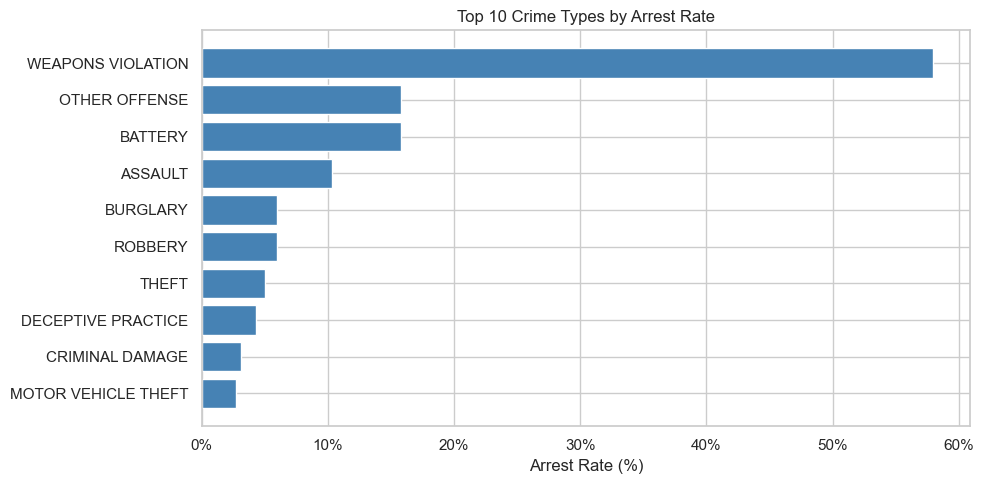

In [35]:
# Figure 1: top crime types by arrest rate
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = crime_type_rates.sort_values('arrest_rate_pct', ascending=True)
ax.barh(plot_df['crime_type'], plot_df['arrest_rate_pct'], color='steelblue')
ax.set_title('Top 10 Crime Types by Arrest Rate')
ax.set_xlabel('Arrest Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

### Crime types by arrest rate.
### Shows that weapons violations have the highest arrest probability.

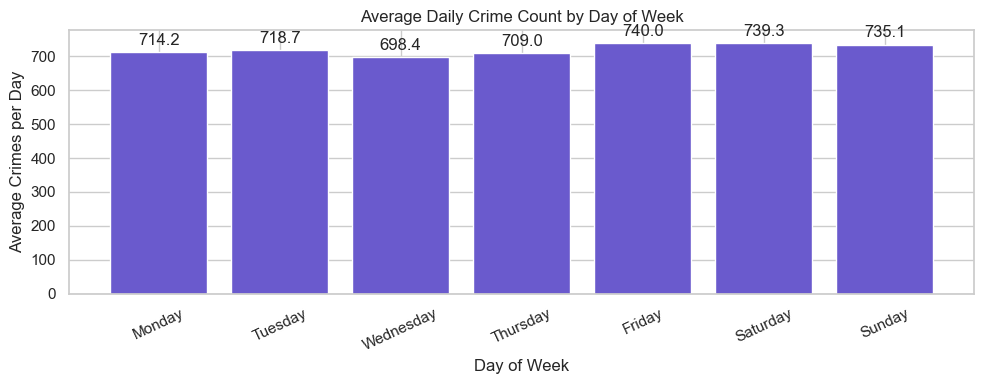

In [36]:
# Figure 2: daily crime counts by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_df = daily_crime.groupby('day_of_week', as_index=False)['crime_count'].mean()
dow_df['day_of_week'] = pd.Categorical(dow_df['day_of_week'], categories=day_order, ordered=True)
dow_df = dow_df.sort_values('day_of_week')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(dow_df['day_of_week'], dow_df['crime_count'], color='slateblue')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title('Average Daily Crime Count by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Crimes per Day')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### Average crime counts by day of week.
### Crime increases toward weekends, especially Friday and Saturday.

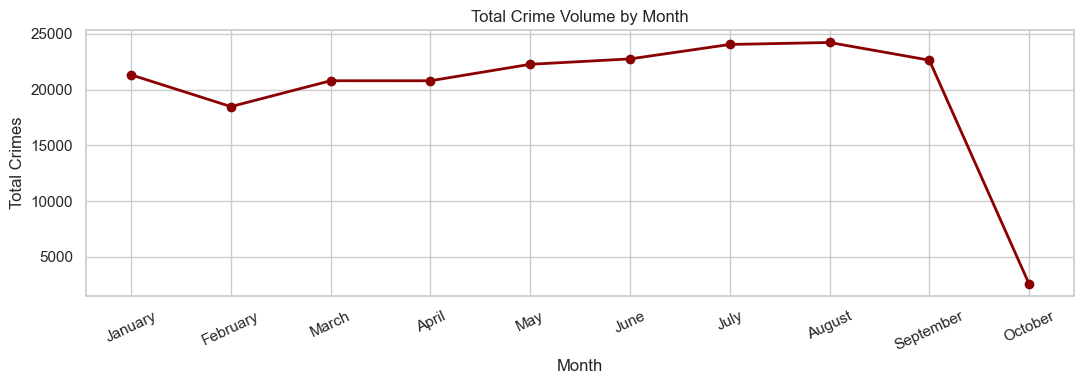

In [37]:
# Figure 3: monthly crime totals
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_df = daily_crime.groupby('month_name', as_index=False)['crime_count'].sum()
month_df['month_name'] = pd.Categorical(month_df['month_name'], categories=month_order, ordered=True)
month_df = month_df.sort_values('month_name')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(month_df['month_name'], month_df['crime_count'], marker='o', color='darkred', lw=2)
ax.set_title('Total Crime Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Crimes')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

### Crime totals by month.
### The chart shows seasonal fluctuations in crime patterns.

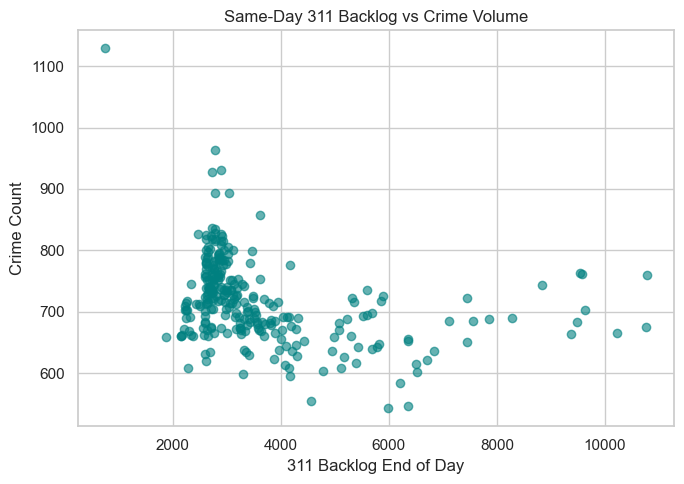

,crime_backlog_corr
0,-0.340028


In [38]:
# Figure 4: same-day crime count vs 311 backlog
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(crime_311_daily['backlog_end_of_day'], crime_311_daily['crime_count'], alpha=0.6, color='teal')
ax.set_title('Same-Day 311 Backlog vs Crime Volume')
ax.set_xlabel('311 Backlog End of Day')
ax.set_ylabel('Crime Count')
plt.tight_layout()
plt.show()

corr_df

### Scatter plot comparing crime counts and 311 backlog.
### The scattered pattern confirms the weak correlation found earlier.

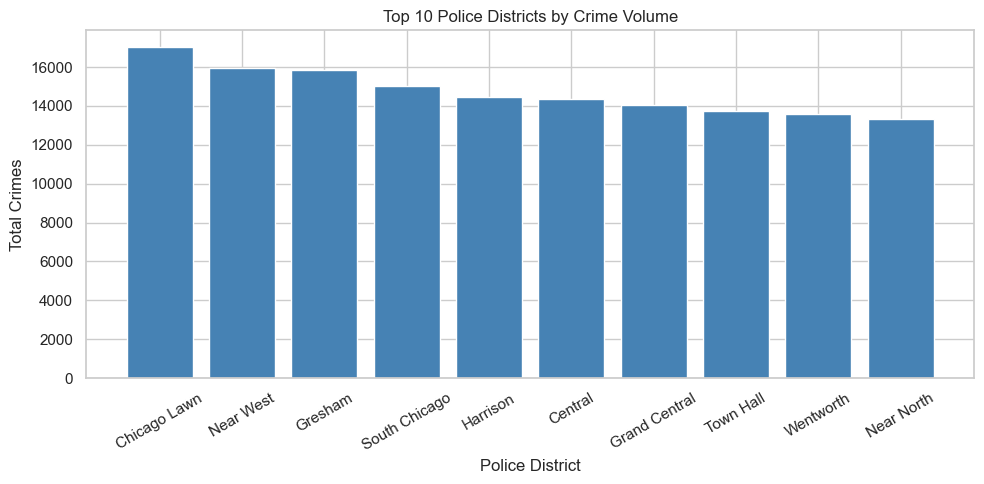

In [39]:
# Figure 5: district crime concentration
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(district_concentration['district_name'], district_concentration['total_crimes'], color='steelblue')
ax.set_title('Top 10 Police Districts by Crime Volume')
ax.set_xlabel('Police District')
ax.set_ylabel('Total Crimes')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### Districts like Chicago Lawn and Near West appear most frequently.

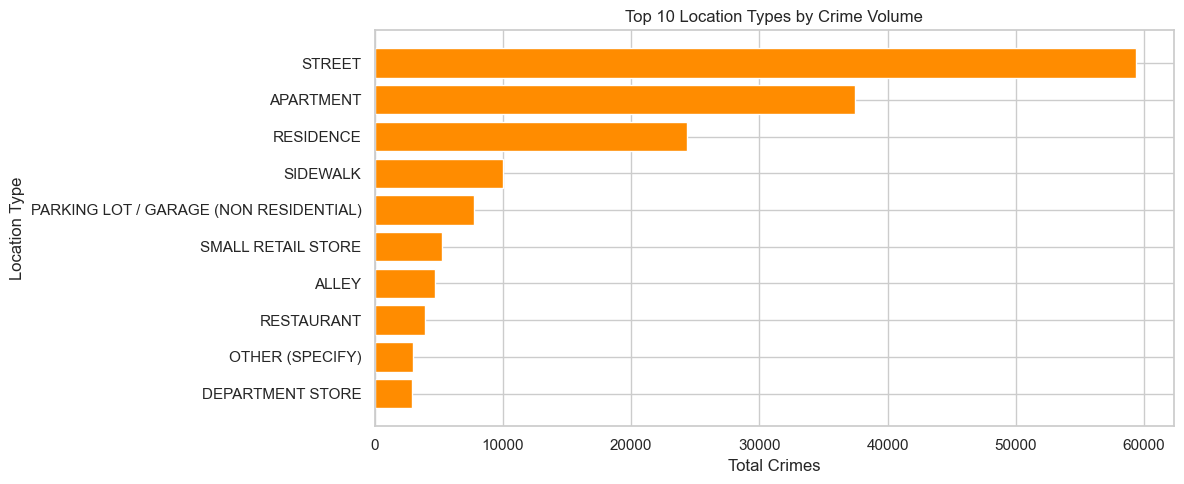

In [40]:
# Figure 6: location-type concentration
fig, ax = plt.subplots(figsize=(12, 5))
plot_loc = location_concentration.sort_values('total_crimes', ascending=True)
ax.barh(plot_loc['location_desc'], plot_loc['total_crimes'], color='darkorange')
ax.set_title('Top 10 Location Types by Crime Volume')
ax.set_xlabel('Total Crimes')
ax.set_ylabel('Location Type')
plt.tight_layout()
plt.show()

### Top location types for crimes.
### Streets and residential areas dominate the dataset.

## Section 6 - Reproducibility Log

In [41]:
con.execute('SELECT * FROM run_manifest ORDER BY run_id DESC').df()

,run_id,run_ts,raw_crimes_rows,stg_crimes_rows,raw_311_rows,stg_311_rows,fact_crime_rows,fact_311_req_rows,fact_311_daily_rows,notes
0,20,2026-03-18 12:00:12.092777,263288,263288,50000,50000,263288,50000,484,Automated build via build.py (crimes + 311)
1,19,2026-03-18 11:33:26.018265,200000,200000,50000,50000,200000,50000,484,Automated build via build.py (crimes + 311)
2,18,2026-03-18 11:30:38.766036,200000,200000,50000,50000,200000,50000,484,Automated build via build.py (crimes + 311)
3,17,2026-03-18 01:14:38.225885,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
4,16,2026-03-18 01:13:14.599924,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
5,15,2026-03-18 01:04:56.493762,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
6,14,2026-03-18 00:59:44.831203,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
7,13,2026-03-18 00:59:31.932743,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
8,12,2026-03-18 00:58:56.759589,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)
9,11,2026-03-18 00:54:20.176638,100000,100000,8911,8911,100000,8911,1375,Automated build via build.py (crimes + 311)


### The pipeline also records runs in a run manifest table, which tracks timestamps and row counts.
### This ensures the analysis is reproducible and auditable.




## Section 7 - Summary and Limitations

### This project demonstrates:
* building a reproducible ETL pipeline
* applying SQL aggregation and analytics
* designing normalized database tables
* analyzing real-world city data.

### This analysis shows how database design and SQL analytics can transform raw city datasets into meaningful insights about crime patterns.

In [42]:
import duckdb

con = duckdb.connect("chicago_crime.duckdb")

tables = [
    "fact_crime_events",
    "fact_311_requests",
    "fact_311_daily",
    "dim_crime_type",
    "dim_district",
    "dim_location_type",
    "dim_police_district_name"
]

for table in tables:
    out_path = f"data/curated/{table}.csv"
    con.execute(f"COPY {table} TO '{out_path}' (HEADER, DELIMITER ',')")
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"Exported -> {out_path} ({count:,} rows)")

con.close()
print("Done.")

Exported -> data/curated/fact_crime_events.csv (263,288 rows)
Exported -> data/curated/fact_311_requests.csv (50,000 rows)
Exported -> data/curated/fact_311_daily.csv (484 rows)
Exported -> data/curated/dim_crime_type.csv (31 rows)
Exported -> data/curated/dim_district.csv (23 rows)
Exported -> data/curated/dim_location_type.csv (132 rows)
Exported -> data/curated/dim_police_district_name.csv (22 rows)
Done.


In [84]:
con.close()
print('Done.')

Done.
